# Object Detection and YOLO


Object detection extends image classification in a critical way: a classifier answers *what is in this image?*, but a detector also answers *where is it?* — and it does so for every object present, not just the dominant one.

This notebook introduces the concepts that make object detection work, then shows how to use YOLO to apply them in practice. Understanding the concepts first makes the YOLO output much easier to reason about.

## Detection, Classification, and Segmentation


Three tasks are often confused because they all process images:

| Task | Question answered | Output |
|------|-------------------|--------|
| **Classification** | What is the dominant object? | One label per image |
| **Detection** | What objects are present, and where? | List of labels + bounding boxes |
| **Segmentation** | Which pixels belong to each object? | Per-pixel label masks |

Detection is harder than classification because the model must simultaneously predict *if* an object exists, *what* it is, and *where* it is — for every object, not just one.

Segmentation goes even further: instead of a rectangle, it delineates the precise shape of each object. You will see an example of this at the end of this notebook when the segmentation YOLO variant is demonstrated.


## Bounding Box Representation


A **bounding box** is a rectangle that encloses an object in an image. It is the most common way to represent object location because it is compact (four numbers) and easy to draw and manipulate.

Two formats appear repeatedly in detection workflows:

1. **Corner format** `(x1, y1, x2, y2)`: top-left corner and bottom-right corner in pixel coordinates. Natural for drawing rectangles.
2. **Center format** `(x_center, y_center, width, height)`: center point plus dimensions. Preferred for training — model outputs are usually parameterised as offsets from anchor centers.

In YOLO label files the values are also **normalised** to the range `[0, 1]` by dividing by image width and height. Normalisation makes labels resolution-independent: the same label file works for a 640×640 version of an image and a 1280×1280 version.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

The two functions below convert between pixel corner format and normalised center format.

A useful mental picture is this:

- `corner format` describes the rectangle by its two opposite corners, so it is ideal for drawing.
- `YOLO format` describes the same rectangle by its center point plus its width and height, so it is easier for the model to predict.

Nothing about the object changes. We are only switching the coordinate system used to describe the same box.

In [ ]:
def corner_to_yolo(box, img_width, img_height):
    """Convert (x1, y1, x2, y2) pixel corners to normalised (cx, cy, w, h)."""
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2) / img_width
    cy = ((y1 + y2) / 2) / img_height
    w  = (x2 - x1) / img_width
    h  = (y2 - y1) / img_height
    return cx, cy, w, h


def yolo_to_corner(box, img_width, img_height):
    """Convert normalised (cx, cy, w, h) to pixel corners (x1, y1, x2, y2)."""
    cx, cy, w, h = box
    x1 = (cx - w / 2) * img_width
    y1 = (cy - h / 2) * img_height
    x2 = (cx + w / 2) * img_width
    y2 = (cy + h / 2) * img_height
    return x1, y1, x2, y2


image_width, image_height = 640, 480
corner_box = (100, 50, 300, 200)
yolo_box   = corner_to_yolo(corner_box, image_width, image_height)
restored   = yolo_to_corner(yolo_box, image_width, image_height)

print(f'Corner format:  {corner_box}')
print(f'YOLO format:    {[f"{v:.3f}" for v in yolo_box]}')
print(f'Back to pixels: {[round(v, 1) for v in restored]}')


Corner format:  (100, 50, 300, 200)
YOLO format:    ['0.312', '0.260', '0.312', '0.312']
Back to pixels: [100.0, 50.0, 300.0, 200.0]


Normalised values remain valid regardless of the image resolution used at inference time, which is why YOLO label files use them. The round-trip conversion confirms that no information is lost when switching formats.


## IoU: Intersection over Union


When a detector predicts a box, we need a way to measure how close it is to the ground-truth annotation.

Think of it as comparing two rectangles for the **same object**:

- the **ground-truth box** was drawn by a human annotator in the labeled dataset
- the **predicted box** was produced by the model at inference time

If the two rectangles overlap well, the prediction is good. If they barely overlap, the prediction is poor even if the class label is correct.

**Intersection over Union (IoU)** compares the overlap between two rectangles:

$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}}$$

- IoU = 1 → perfect overlap (predicted box matches ground truth exactly).
- IoU = 0 → no overlap at all.
- Any value in between tells us how close the prediction is.

IoU appears in two very different places in a detection pipeline:

1. **Evaluation**: given a predicted box and a ground-truth box, IoU decides whether the prediction counts as a true positive (often the threshold is 0.5).
2. **Post-processing**: given two heavily overlapping predicted boxes, IoU decides whether one is a redundant duplicate that should be removed — this is Non-Maximum Suppression.


In [ ]:
def calculate_iou(box1, box2):
    # The intersection rectangle is bounded by the inner corners of the two boxes.
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # If the boxes do not overlap, one or both dimensions of the intersection are negative.
    # Clamping to zero gives an intersection area of zero in that case.
    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    # Union counts each pixel exactly once: add both areas, subtract the overlap.
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0


box_a = (100, 100, 200, 200)
box_b = (150, 150, 250, 250)
print(f'IoU between box_a and box_b: {calculate_iou(box_a, box_b):.3f}')


IoU between box_a and box_b: 0.143


The plot below makes the overlap region visible.


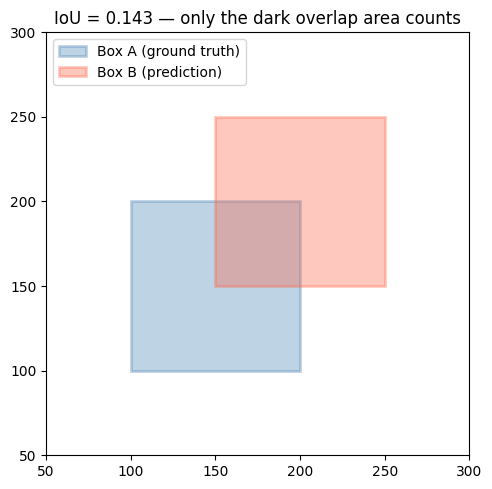

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(patches.Rectangle((100,100), 100, 100, linewidth=2,
    edgecolor='steelblue', facecolor='steelblue', alpha=0.35, label='Box A (ground truth)'))
ax.add_patch(patches.Rectangle((150,150), 100, 100, linewidth=2,
    edgecolor='tomato', facecolor='tomato', alpha=0.35, label='Box B (prediction)'))
ax.set_xlim(50, 300); ax.set_ylim(50, 300); ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.set_title(f'IoU = {calculate_iou(box_a, box_b):.3f} — only the dark overlap area counts')
plt.tight_layout(); plt.show()


## Non-Maximum Suppression (NMS)

A detector does not output one box per object. It produces many candidate boxes (one from each position and scale it considers) and a confidence score for each.

[![](../resources/images/nms.png)](https://www.analyticsvidhya.com/blog/2020/08/selecting-the-right-bounding-box-using-non-max-suppression-with-implementation/)

In practice this means the same pedestrian might produce a dozen overlapping boxes with slightly different coordinates. We need a way to keep only the best one.

**Non-Maximum Suppression** solves this with a greedy algorithm:

1. Sort all remaining boxes by confidence score (highest first).
2. Keep the highest-confidence box.
3. Discard every remaining box whose IoU with the kept box exceeds the threshold (they are too similar to be separate objects).
4. Repeat from step 1 with the surviving boxes.

The key intuition: high overlap + lower confidence = redundant detection, not a second object. NMS does not depend on the model itself; it is applied to the raw output to clean it up.

[![](../resources/images/nms2.png)](https://blog.cubed.run/nms-non-maximum-suppression-157be5bc61ca)

In [ ]:
def nms(boxes, scores, iou_threshold=0.5):
    # Argsort returns indices that would sort scores ascending; [::-1] reverses to descending.
    indices = np.argsort(scores)[::-1]
    keep = []

    while len(indices) > 0:
        current = indices[0]   # highest-scoring box still under consideration
        keep.append(current)

        if len(indices) == 1:
            break

        # Keep only boxes that do not overlap too much with the chosen box.
        # Overlap above threshold => likely the same object => suppress.
        remaining = [i for i in indices[1:] if calculate_iou(boxes[current], boxes[i]) < iou_threshold]
        indices = remaining

    return keep


boxes = [
    (100, 100, 200, 200),          # strongest detection of object A
    (110, 105, 210, 205),          # duplicate of A (suppressed)
    (105, 102, 205, 202),          # another duplicate of A (suppressed)
    (300, 300, 400, 400),          # object B, far away (kept)
]
scores = [0.9, 0.75, 0.8, 0.85]

kept = nms(boxes, scores, iou_threshold=0.5)
print(f'Before NMS: {len(boxes)} boxes')
print(f'After NMS:  {len(kept)} boxes  (indices: {kept})')


Before NMS: 4 boxes
After NMS:  2 boxes  (indices: [np.int64(0), np.int64(3)])


The fourth box (index 3) is far away and has essentially zero IoU with the others, so it survives NMS. The first box (index 0) is kept because it has the highest confidence. Boxes 1 and 2 overlap too much with box 0 and are suppressed.


## Detection Metrics


After running a detector on a validation set, we need a number that summarises quality.

### Precision and Recall

| Outcome | Meaning |
|---------|:--------|
| **True Positive (TP)** | Predicted box matches a ground-truth box (IoU > threshold) |
| **False Positive (FP)** | Predicted box does not match any ground truth — a **hallucination** |
| **False Negative (FN)** | A real object was never detected |

In detection, we evaluate predicted **boxes**, not just one label per image.  
That makes “true negatives” ill-defined (or overwhelmingly dominant, depending on how you count background locations), so accuracy is not a useful metric. Instead we use:

$$\text{Precision} = \frac{TP}{TP + FP}$$

*Of all boxes the model predicted, how many were actually correct?*

$$\text{Recall} = \frac{TP}{TP + FN}$$

*Of all real objects in the image, how many did the model find?*

There is a natural tension: increasing confidence threshold raises precision but lowers recall; decreasing it raises recall but admist more false positives.

### mAP

**mAP (mean Average Precision)** summarises the precision-recall tradeoff over all confidence thresholds and all classes. Two variants appear in YOLO training logs:

- **mAP50**: IoU threshold fixed at 0.5 — considers a prediction correct if box overlap ≥ 50 %.
- **mAP50-95**: averaged over thresholds from 0.50 to 0.95 in steps of 0.05 — a stricter metric that also penalises imprecise box placement.

In practice: if mAP50 is much higher than mAP50-95, the model finds objects but does not localise them tightly.


## How YOLO Works


### The Two-Stage vs One-Stage Split

Early deep-learning detectors were **two-stage**: first propose candidate regions, then classify each one. Examples are Faster R-CNN and its predecessors. They are often accurate, but the two-pass structure adds latency.

**One-stage detectors** skip the proposal step and predict boxes and class scores directly from a single forward pass through the network. YOLO, SSD, and RetinaNet are examples.

| Approach | Typical speed | Accuracy tendency | Common use |
|----------|--------------|-------------------|-----------|
| Two-stage | Slower | Often higher | Offline analysis |
| One-stage | Faster | Very competitive | Real-time, edge devices |

### YOLO's Internal Structure

Modern YOLO models are composed of three functional blocks:

1. **Backbone**: a CNN (or Vision Transformer) that extracts feature maps at multiple spatial resolutions from the input image.
2. **Neck**: aggregates features from different resolutions so the detector can handle both small objects (need fine-grained detail) and large objects (need broad context). PAN (Path Aggregation Network) and FPN (Feature Pyramid Network) are common neck designs.
3. **Detection head**: for each spatial position and each scale, predicts bounding box offsets, objectness score, and class probabilities.

The data flow is:

```
image  →  backbone  →  multi-scale feature maps  →  neck  →  head
                                                              ↓
                             NMS  ←  raw candidates (thousands of boxes)
                              ↓
                        final detections (typically < 100)
```

**A note on anchor boxes**: older YOLO explanations are built around fixed anchor boxes matched to ground-truth objects during training. That concept is useful for understanding the history, but recent Ultralytics YOLO versions are largely **anchor-free** — the head predicts box coordinates as direct offsets without predefined anchor shapes.

### YOLO Versions

| Version | Year | Key contribution |
|---------|------|------------------|
| YOLOv1 | 2016 | Single-pass detection; grid-based formulation |
| YOLOv2/9000 | 2017 | Anchor boxes; multi-scale training |
| YOLOv3 | 2018 | Multi-scale feature map predictions |
| YOLOv4 | 2020 | Strong data augmentation; composite backbone |
| YOLOv5 | 2020 | Clean PyTorch implementation; easy adoption |
| YOLOv8 | 2023 | Unified Ultralytics API; anchor-free head |
| YOLOv11 | 2024 | Further refinements in the Ultralytics ecosystem |


## YOLO in Practice


The rest of this notebook uses the **Ultralytics** library, which provides a unified Python API for loading models, running inference, and inspecting results.

Install it if needed:

```bash
pip install ultralytics   # or: uv add ultralytics
```


In [ ]:
import os
from pathlib import Path
from ultralytics import YOLO, settings
import cv2

# Store downloaded model weights in a local subfolder instead of the global cache.
MODELS_DIR = Path('../resources/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
settings.update({'weights_dir': str(MODELS_DIR.resolve())})

# Inference outputs (annotated images, etc.) go here.
OUTPUT_DIR = Path('../artifacts/outputs/yolo_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Loading a Pre-trained Model


A **pre-trained model** carries weights already learned from a large labelled dataset. We do not need to train anything — we can use these weights directly for inference.

The Ultralytics YOLO models are pre-trained on **COCO** (Common Objects in Context): a dataset of about 330,000 images covering 80 everyday object categories (people, vehicles, animals, household objects, and more). This means the model 'knows' those 80 classes out of the box — but nothing beyond them, unless we fine-tune it later.

Model size variants trade speed against accuracy:

| Suffix | Size | Speed | Notes |
|--------|------|-------|-------|
| `n` | Nano | Fastest | Good starting point for teaching |
| `s` | Small | Fast | |
| `m` | Medium | Moderate | |
| `l` | Large | Slower | |
| `x` | Extra-large | Slowest | Highest accuracy |


In [ ]:
# YOLO() downloads the weights automatically on the first run.
model = YOLO(MODELS_DIR / 'yolov8n.pt')

print(f'Model: {model.model_name}')
print(f'Classes ({len(model.names)} total from COCO):')
print({k: v for k, v in list(model.names.items())[:10]}, '...')


Model: ../resources/models/yolov8n.pt
Classes (80 total from COCO):
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light'} ...


## Running Inference


We use `resources/images/bus.jpg` — a classic YOLO demo image included in the repository. It shows a street scene with a bus and several pedestrians, which is a good test for a COCO-pretrained model since those are COCO classes.

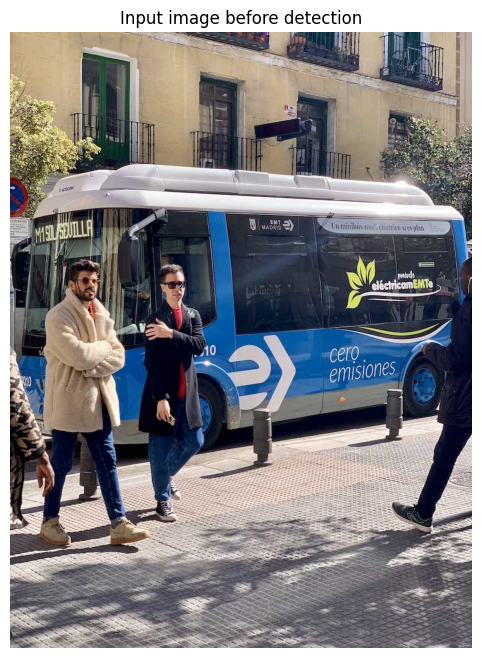

In [ ]:
sample_path = Path('../resources/images/bus.jpg')

# Show the image before detection
img = cv2.imread(str(sample_path))
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input image before detection')
plt.show()

`model()` accepts a path (or URL, NumPy array, etc.) and returns a list of `Results` objects — one per input image. Each `Results` object holds all predicted boxes for that image.


In [ ]:
results = model(sample_path, save=True, project=str(OUTPUT_DIR))
result  = results[0]  # only one image was passed

print(f'Detected {len(result.boxes)} objects')
for box in result.boxes:
    cls_id = int(box.cls[0])          # integer class index
    conf   = float(box.conf[0])        # confidence 0–1
    xyxy   = box.xyxy[0].cpu().numpy() # pixel corners
    print(f'  {model.names[cls_id]:<12}  conf={conf:.2f}  box={xyxy.astype(int)}')

image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision/yolo/../resources/images/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 50.1ms
Speed: 2.4ms preprocess, 50.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/artifacts/outputs/yolo_outputs/predict4
Detected 6 objects
  bus           conf=0.87  box=[ 22 231 805 756]
  person        conf=0.87  box=[ 48 398 245 902]
  person        conf=0.85  box=[669 392 809 877]
  person        conf=0.83  box=[221 405 344 857]
  person        conf=0.26  box=[  0 550  63 873]
  stop sign     conf=0.26  box=[  0 254  32 324]


The `result.plot()` method draws all detected boxes and labels directly on the image.


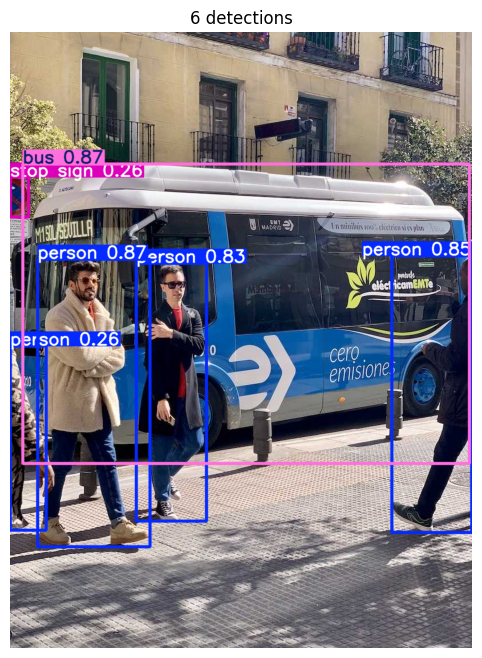

In [ ]:
annotated = result.plot()
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'{len(result.boxes)} detections')
plt.show()

## Coordinate Formats


Three coordinate formats appear in the YOLO API. Choosing the right one depends on what you do next:

| Attribute | Format | Values | Use case |
|-----------|--------|--------|----------|
| `box.xyxy` | `(x1, y1, x2, y2)` | Pixels | Drawing boxes, cropping regions |
| `box.xywh` | `(cx, cy, w, h)` | Pixels | Geometric calculations |
| `box.xywhn` | `(cx, cy, w, h)` | Normalised 0–1 | Matches YOLO label file format |

These are the same three formats introduced earlier in the notebook — the conversion functions we wrote are exactly what the API does internally.


In [ ]:
for box in result.boxes:
    print('xyxy  (pixel corners):         ', box.xyxy[0].cpu().numpy())
    print('xywh  (pixel centre + size):   ', box.xywh[0].cpu().numpy())
    print('xywhn (normalised centre+size):', box.xywhn[0].cpu().numpy())
    break  # one detection is enough to illustrate


xyxy  (pixel corners):          [     22.871      231.28         805      756.84]
xywh  (pixel centre + size):    [     413.94      494.06      782.13      525.56]
xywhn (normalised centre+size): [    0.51103     0.45746     0.96559     0.48663]


## Filtering Detections


Inference parameters let you control which detections are returned. The defaults are `conf=0.25` and `iou=0.45`.

- `conf` — minimum confidence score; detections below this are silently discarded. Raising it trades recall for precision: fewer results, but more trustworthy.
- `classes` — whitelist of class IDs; other classes are ignored even with high confidence. Class indices follow the COCO ordering (0 = person, 2 = car, 5 = bus, …).
- `iou` — IoU threshold used inside NMS. Raising it makes NMS more permissive: two boxes must overlap by *more* than this fraction before one is suppressed. This can preserve genuinely close objects that the default threshold would wrongly merge. Note: Ultralytics NMS is class-agnostic by default, so a low `iou` can suppress detections across different classes when their boxes happen to overlap (e.g. a person box inside a bus box).


In [ ]:
def labels(result):
    return [model.names[int(b.cls[0])] for b in result.boxes]

# Baseline: default parameters (conf=0.25, iou=0.45)
results_base = model(sample_path, verbose=False)
print(f'baseline       {len(results_base[0].boxes)} detections — {labels(results_base[0])}')

# Raising conf to 0.5 drops low-confidence detections
results_conf = model(sample_path, conf=0.5, verbose=False)
print(f'conf=0.5       {len(results_conf[0].boxes)} detections — {labels(results_conf[0])}')

# Whitelist: only persons (0) and cars (2); the bus (class 5) is ignored regardless of confidence
results_cls = model(sample_path, classes=[0, 2], verbose=False)
print(f'classes=[0,2]  {len(results_cls[0].boxes)} detections — {labels(results_cls[0])}')

# Permissive NMS (iou=0.7): boxes must overlap by > 70 % before one is suppressed.
# This is useful when densely packed objects of the same class are being wrongly merged.
results_iou = model(sample_path, iou=0.7, verbose=False)
print(f'iou=0.7        {len(results_iou[0].boxes)} detections — {labels(results_iou[0])}')


baseline       6 detections — ['bus', 'person', 'person', 'person', 'person', 'stop sign']
conf=0.5       4 detections — ['bus', 'person', 'person', 'person']
classes=[0,2]  4 detections — ['person', 'person', 'person', 'person']
iou=0.7        4 detections — ['person', 'person', 'person', 'person']


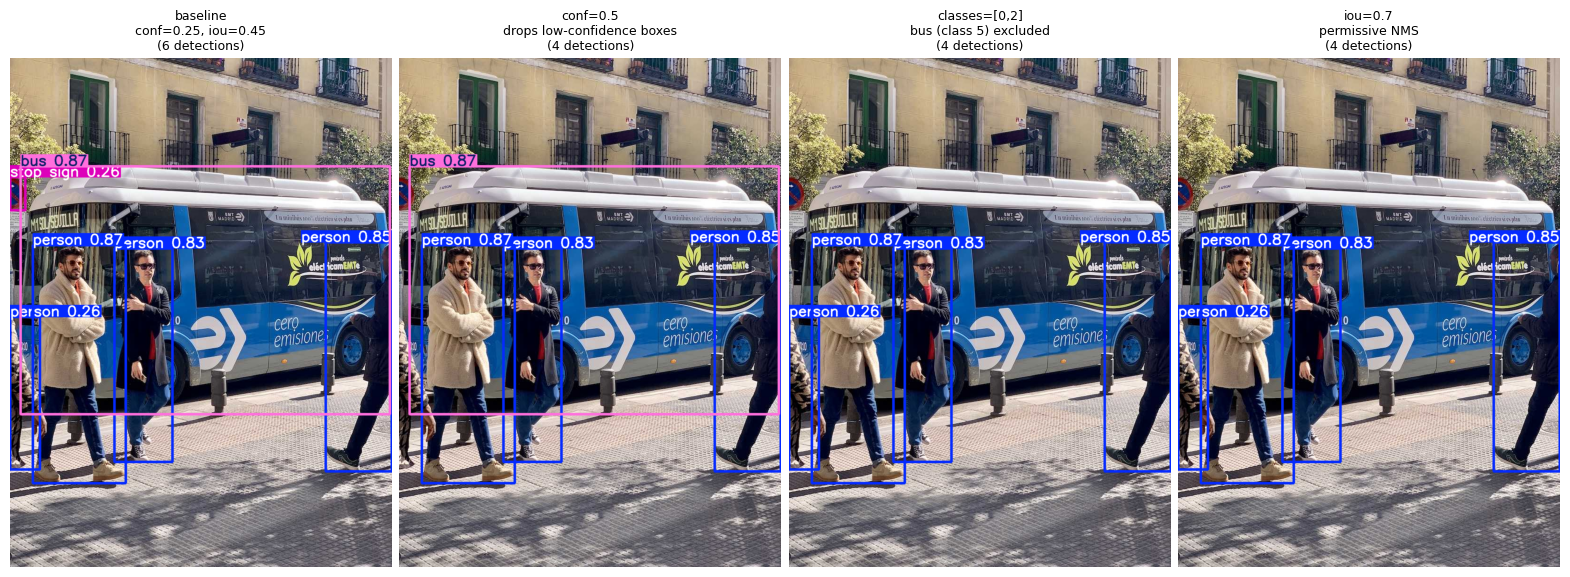

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))
fig.subplots_adjust(wspace=0.02)

configs = [
    (results_base[0], 'baseline\nconf=0.25, iou=0.45'),
    (results_conf[0], 'conf=0.5\ndrops low-confidence boxes'),
    (results_cls[0],  'classes=[0,2]\nbus (class 5) excluded'),
    (results_iou[0],  'iou=0.7\npermissive NMS'),
]

for ax, (r, title) in zip(axes, configs):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f'{title}\n({len(r.boxes)} detections)', fontsize=9)
    ax.axis('off')

plt.show()


## Video Inference


YOLO processes video as a sequence of frames. The only practical change from image inference is the `stream=True` flag, which turns the call into a generator rather than collecting all results in memory at once. This is important for long videos.

The relationship between model speed and video inference is direct: a model that takes 50 ms per frame supports at most 20 FPS. Model size, input resolution, hardware, and batch size all affect latency. We put this into perspective in the model-comparison section below.

The code downloads a short sample video for the demo. Videos are not committed to the repository because of their file size, but the download runs once and is reused.


In [ ]:
import urllib.request

video_url  = 'https://github.com/ultralytics/assets/releases/download/v0.0.0/decelera_portrait_min.mov'
video_path = OUTPUT_DIR / 'sample_video.mov'

if not video_path.exists():
    try:
        urllib.request.urlretrieve(video_url, str(video_path))
        print(f'Downloaded to {video_path}')
    except Exception as e:
        print(f'Download failed: {e}')
        video_path = None


In [ ]:
if video_path and video_path.exists():
    # stream=True: decode and process frames one at a time instead of loading
    # the whole video into memory. Essential for long videos.
    results_video = model(str(video_path), stream=True, save=True, project=str(OUTPUT_DIR))

    frame_count = 0
    for r in results_video:
        frame_count += 1
        if frame_count >= 5:
            break

    print(f'Processed {frame_count} frames (demo limited to 5)')


Processed 5 frames (demo limited to 5)


## Segmentation and Other Tasks


Ultralytics provides task-specific model variants using the same API. Segmentation models produce per-pixel masks in addition to bounding boxes, answering the more precise question *which pixels belong to this object?* rather than just *where is the box?*

You can tell what task a model performs from its filename suffix:

| Filename | Task |
|----------|---------|
| `yolov8n.pt` | Detection (boxes only) |
| `yolov8n-seg.pt` | Instance segmentation |
| `yolov8n-pose.pt` | Human pose estimation |
| `yolov8n-cls.pt` | Image classification |


In [ ]:
seg_model   = YOLO(MODELS_DIR / 'yolov8n-seg.pt')
seg_results = seg_model(sample_path, save=True, project=str(OUTPUT_DIR))

if seg_results[0].masks is not None:
    print(f'Masks tensor shape: {seg_results[0].masks.data.shape}')
    print('First dimension = number of detected objects')
    print('Remaining dimensions = mask resolution (may differ from input image size)')



image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision/yolo/../resources/images/bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 62.3ms
Speed: 2.3ms preprocess, 62.3ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/artifacts/outputs/yolo_outputs/predict6
Masks tensor shape: torch.Size([6, 640, 480])
First dimension = number of detected objects
Remaining dimensions = mask resolution (may differ from input image size)


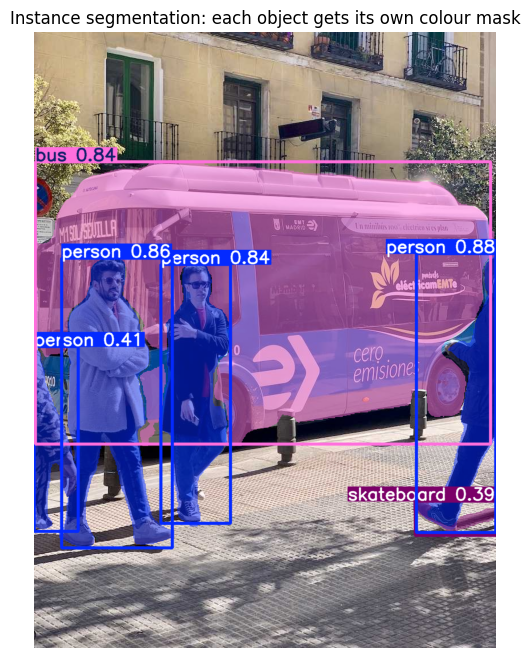

In [ ]:
seg_annotated = seg_results[0].plot()
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(seg_annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Instance segmentation: each object gets its own colour mask')
plt.show()


## Model Comparison: Speed vs Accuracy


Choosing a model size is a practical tradeoff. The benchmark below times 10 consecutive inferences after a warmup run (the first inference is usually slower because of GPU kernel compilation or memory allocation, so it is excluded from the measurement).


In [ ]:
import time

for model_name in ['yolov8n.pt', 'yolov8s.pt']:
    m = YOLO(MODELS_DIR / model_name)
    m(sample_path, verbose=False)  # warmup

    t0 = time.time()
    for _ in range(10):
        m(sample_path, verbose=False)
    ms_per_image = (time.time() - t0) / 10 * 1000

    print(f'{model_name:20}  {ms_per_image:.1f} ms/image  ({1000/ms_per_image:.0f} FPS theoretical)')


yolov8n.pt            51.6 ms/image  (19 FPS theoretical)
yolov8s.pt            113.0 ms/image  (9 FPS theoretical)


These numbers depend heavily on hardware. On a CPU the difference between nano and small may be 2–3×; on a GPU it narrows considerably. For deployment decisions, measure on the target device.


## Exporting for Deployment


A model trained or fine-tuned in Python can be exported to a format that runs in a different environment. Each export target is suited to different deployment scenarios:

| Format | Use case |
|--------|---------|
| `onnx` | Cross-platform; supported by ONNX Runtime, TensorRT, OpenCV DNN, … |
| `torchscript` | Staying in the PyTorch ecosystem without a Python interpreter |
| `coreml` | macOS and iOS (Apple Silicon or Neural Engine) |
| `tflite` | Android and microcontrollers |
| `engine` | NVIDIA TensorRT for maximum GPU throughput |

The choice depends entirely on where the model will be deployed, not on the training framework.


In [ ]:
# Uncomment to export. The exported file appears next to the weights.
# model.export(format='onnx')

export_info = [
    ('onnx',        'Cross-platform, CPU/GPU'),
    ('torchscript', 'PyTorch deployment (no Python)'),
    ('coreml',      'macOS / iOS'),
    ('tflite',      'Android / Edge devices'),
    ('engine',      'NVIDIA TensorRT'),
]

print('Available export formats:')
for fmt, desc in export_info:
    print(f'  {fmt:<14} {desc}')


Available export formats:
  onnx           Cross-platform, CPU/GPU
  torchscript    PyTorch deployment (no Python)
  coreml         macOS / iOS
  tflite         Android / Edge devices
  engine         NVIDIA TensorRT


## Summary


| Concept | Key point |
|---------|----------|
| **Bounding box** | Four numbers (corner or centre format) that localise an object |
| **IoU** | Overlap ratio; used in evaluation (TP/FP decision) and in NMS (duplicate removal) |
| **NMS** | Greedy algorithm that removes lower-confidence duplicates |
| **mAP50 / mAP50-95** | Standard metrics; mAP50-95 also penalises imprecise box placement |
| **YOLO** | One-stage detector; fast, practical, one API call for images and video |
| **Coordinate formats** | xyxy for drawing, xywh for geometry, xywhn for label files |
| **Model variants** | `n` → `s` → `m` → `l` → `x`: larger is slower but more accurate |
